In [117]:
import json
import numpy as np
import matplotlib.pyplot as plt
import math

def visualize_pigment_grid(json_path, title="Pigment Reflectance Grid", normalized=True):
    """
    PURPOSE:
        Displays a grid of reflectance curves for all pigments in a JSON file.
        Useful for visually auditing Stage 0, Stage 1, or later stages.

    INPUT:
        json_path : path to a stage JSON file (e.g., stage1_standardized_data.json)

    BEHAVIOR:
        - Creates a grid of subplots
        - Each subplot shows one pigment's reflectance curve
        - Automatically adjusts grid size based on pigment count
    """

    # --- Load JSON ---
    with open(json_path, 'r') as f:
        data = json.load(f)

    n = len(data)
    cols = 5
    rows = math.ceil(n / cols)

    plt.figure(figsize=(cols * 4, rows * 3))
    plt.suptitle(title, fontsize=18, fontweight='bold')

    for i, pigment in enumerate(data):
        w = np.array(pigment["wavelengths"])
        r = np.array(pigment["reflectance"])

        ax = plt.subplot(rows, cols, i + 1)
        ax.plot(w, r, color="blue", linewidth=1.5)

        ax.set_title(pigment["name"], fontsize=9)
        if normalized:
            ax.set_ylim(0, 1)
        else:
            ax.set_ylim(0, 100)
        ax.set_xlim(w.min(), w.max())
        ax.grid(True, alpha=0.3)

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

✅ Stage 0 Optimized Complete: 81 pigments saved.


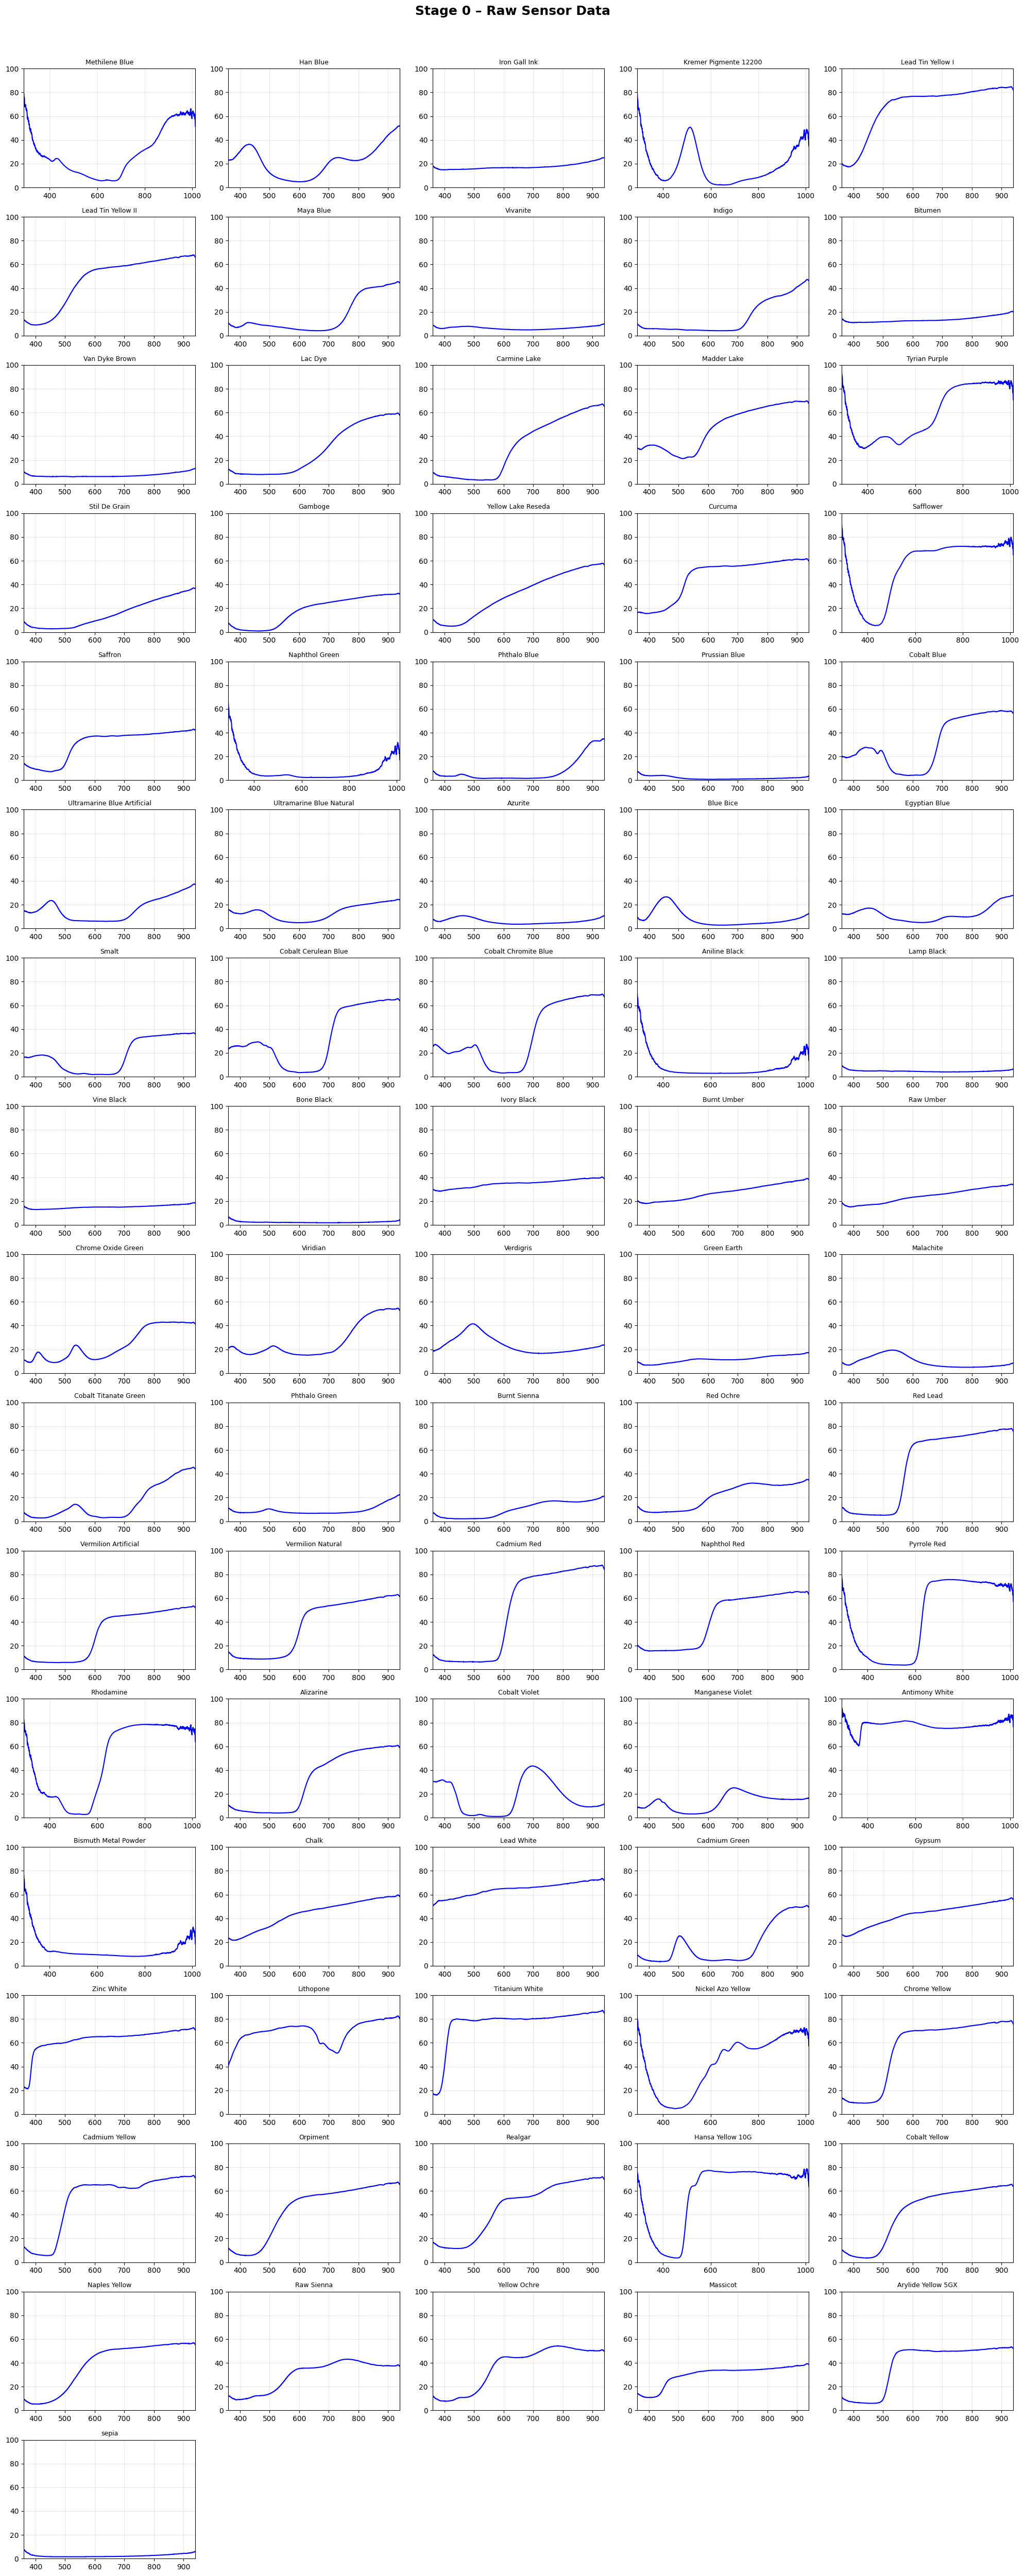

In [119]:
import os
import json
import numpy as np

# Define your paths
SOURCE_DIR = './SoT'
OUTPUT_DIR = './spectral_pipeline_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

def stage0_ingest_optimized(source_path, output_path):
    """
    PURPOSE: Converts .txt files into a structured JSON with flattened arrays.
    FORMAT: 
        - index: "PBk9"
        - name: "Ivory Black"
        - wavelengths: [350.0, 351.0, ...]
        - reflectance: [2.5, 2.6, ...] (Percentages)
    """
    raw_library = []
    files = [f for f in os.listdir(source_path) if f.endswith('.txt')]
    
    for file_name in files:
        file_path = os.path.join(source_path, file_name)
        try:
            # 1. Parse File Name (e.g. 'PBk9_Ivory_Black.txt')
            clean_filename = file_name.replace('.txt', '')
            parts = clean_filename.split('_', 1) if "_" in clean_filename else ["NA", clean_filename]
            
            # 2. Load Data directly into NumPy
            data = np.loadtxt(file_path)
            
            # 3. Flatten the columns for the JSON
            # We keep them as raw percentages (0-100) and raw wavelengths for now
            raw_library.append({
                "index": parts[0],
                "name": parts[1].replace('_', ' '),
                "wavelengths": data[:, 0].tolist(),
                "reflectance": data[:, 1].tolist()
            })
            
        except Exception as e:
            print(f"⚠️ Error reading {file_name}: {e}")

    # 4. Save to Output folder
    json_path = os.path.join(output_path, "stage0_raw_data.json")
    with open(json_path, 'w') as f:
        json.dump(raw_library, f, indent=4)
    
    print(f"✅ Stage 0 Optimized Complete: {len(raw_library)} pigments saved.")
    return raw_library

# --- RUN ---
stage0_data = stage0_ingest_optimized(SOURCE_DIR, OUTPUT_DIR)
visualize_pigment_grid("./spectral_pipeline_output/stage0_raw_data.json",
                       title="Stage 0 – Raw Sensor Data", normalized=False)


In [120]:
def test_stage0_flattened(data_list):
    sample = next((p for p in data_list if "Ivory Black" in p['name']), None)
    
    if sample:
        w = np.array(sample['wavelengths'])
        r = np.array(sample['reflectance'])
        
        print(f"📊 {sample['name']} Stats:")
        print(f"   Wavelength Range: {w.min()}nm to {w.max()}nm")
        print(f"   Data Points: {len(r)}")
        
        # Verify they are the same length
        assert len(w) == len(r), "Mismatched array lengths!"
        print("✅ Arrays are perfectly aligned.")
    else:
        print("❌ Sample not found.")

test_stage0_flattened(stage0_data)


📊 Ivory Black Stats:
   Wavelength Range: 360.161nm to 939.93nm
   Data Points: 2956
✅ Arrays are perfectly aligned.


✅ Stage 1 Complete: 81 pigments standardized to 5nm grid.


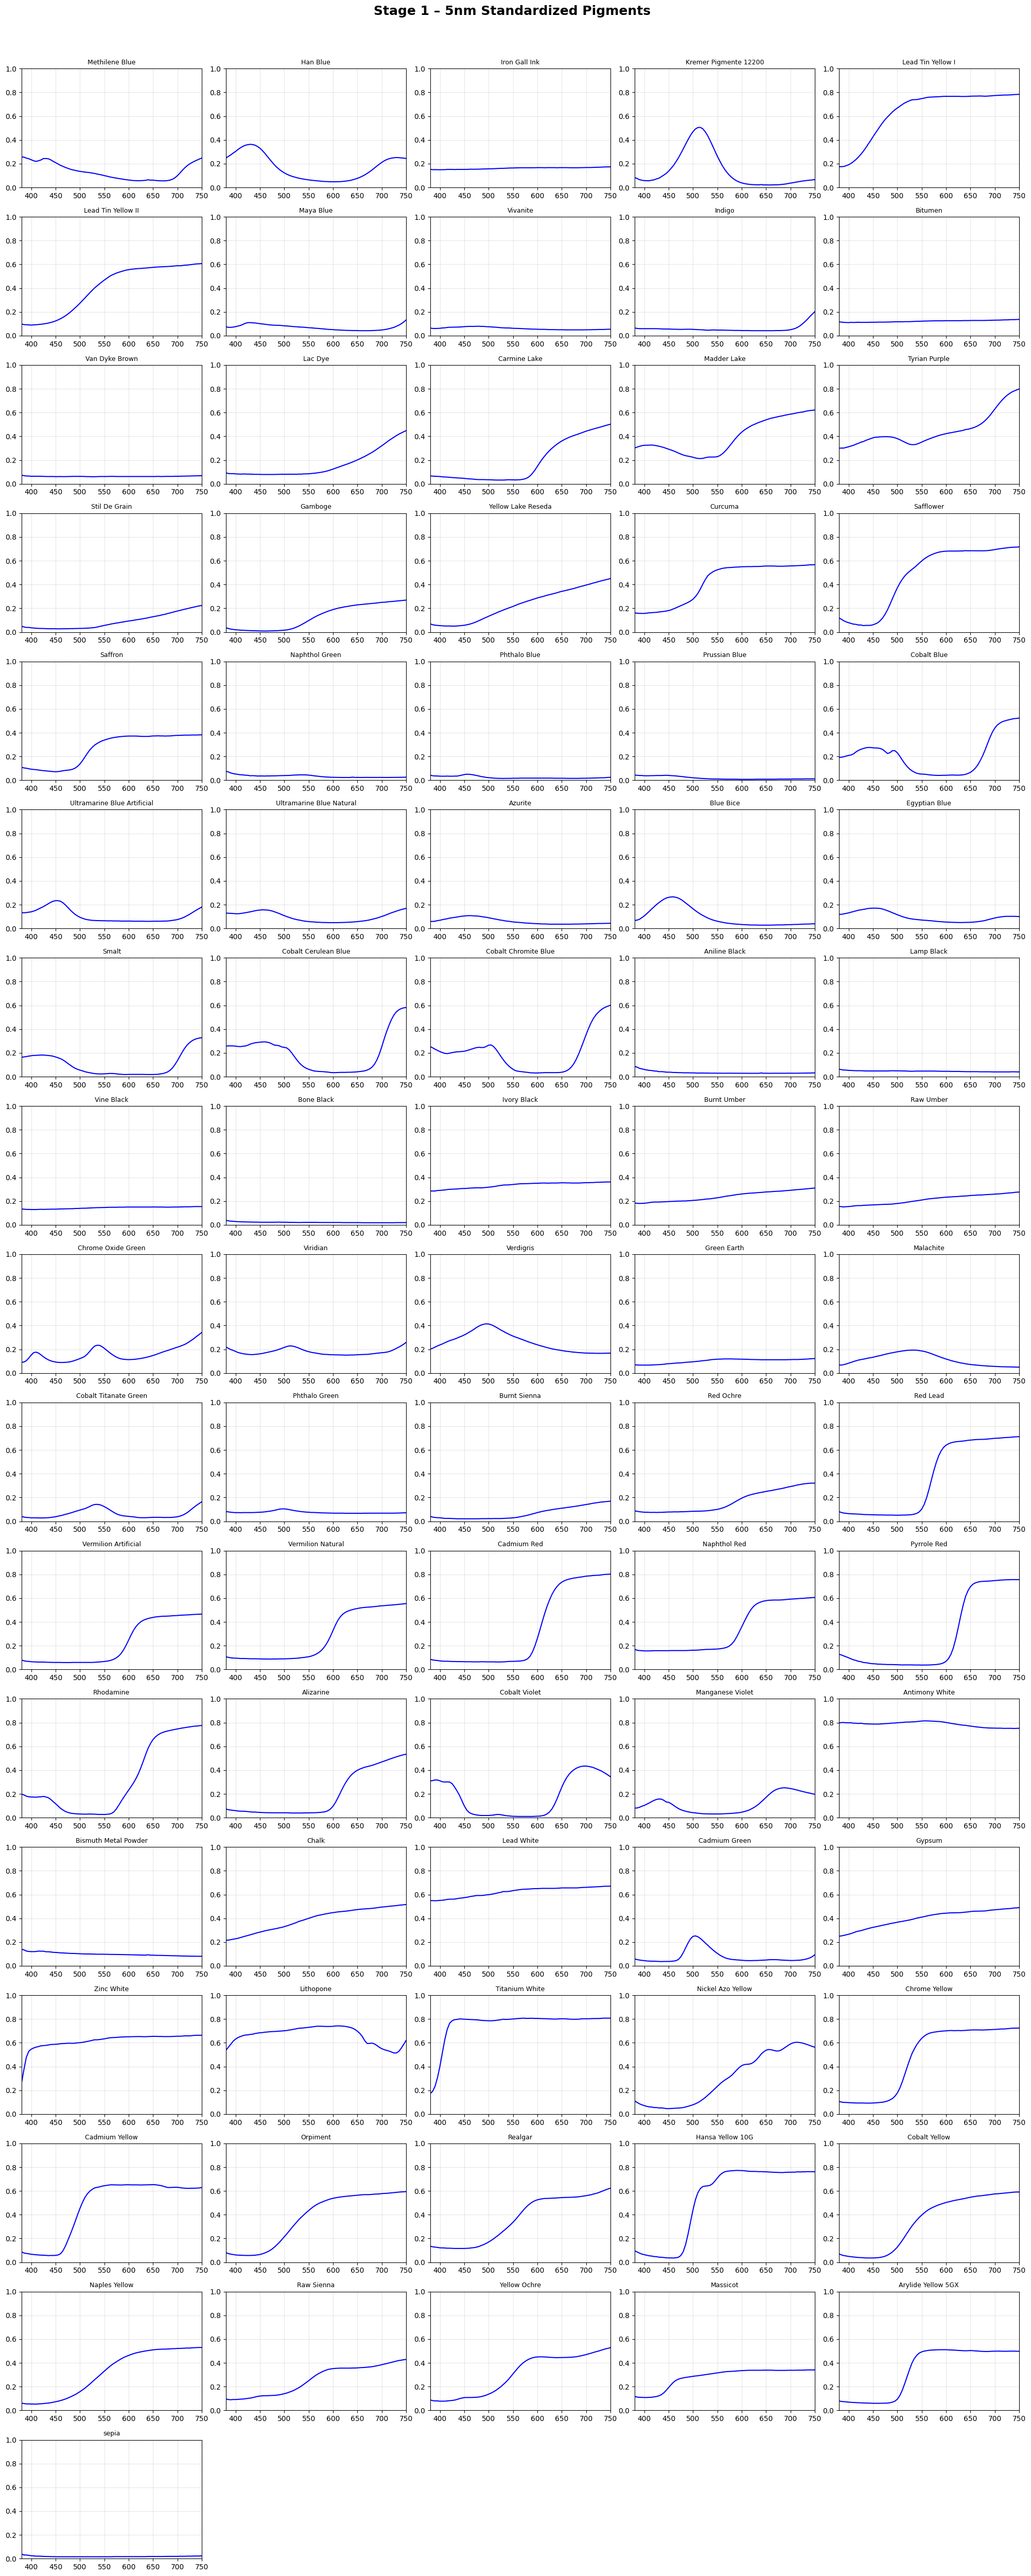

In [121]:
import os
import json
import numpy as np
from scipy.interpolate import CubicSpline

# Paths
INPUT_JSON = './spectral_pipeline_output/stage0_raw_data.json'
OUTPUT_DIR = './spectral_pipeline_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

def stage1_standardize_data(input_path, output_path):
    """
    PURPOSE: Normalizes raw data to a professional 5nm grid (360-800nm).
    SCIENCE: 
        - Decimal Conversion (0-100% -> 0.0-1.0)
        - Cubic Spline Interpolation (Smooths sensor noise)
        - Clipping (Ensures physical reality: 0 <= R <= 1)
    """
    with open(input_path, 'r') as f:
        raw_data = json.load(f)
    
    standardized_library = []
    
    # Define our target grid: 380 to 750 (inclusive) in 5nm steps = 75 points
    target_w = np.arange(380, 751, 5) 
    
    for p in raw_data:
        try:
            # 1. Load raw arrays
            w_raw = np.array(p['wavelengths'])
            r_raw = np.array(p['reflectance']) / 100.0 # Convert to decimal immediately
            
            # 2. Cubic Spline Interpolation
            # 'bc_type="natural"' ensures the ends of the spectrum don't waggle
            cs = CubicSpline(w_raw, r_raw, bc_type='natural')
            
            # 3. Resample to our 89-point grid
            r_std = cs(target_w)
            
            # 4. Physical Reality Check (Clip values to 0.0 - 1.0)
            r_std = np.clip(r_std, 0.0, 1.0)
            
            standardized_library.append({
                "index": p['index'],
                "name": p['name'],
                "wavelengths": target_w.tolist(),
                "reflectance": r_std.tolist()
            })
            
        except Exception as e:
            print(f"⚠️ Error standardizing {p['name']}: {e}")

    # 5. Save to Stage 1 JSON
    json_path = os.path.join(output_path, "stage1_standardized_data.json")
    with open(json_path, 'w') as f:
        json.dump(standardized_library, f, indent=4)
    
    print(f"✅ Stage 1 Complete: {len(standardized_library)} pigments standardized to 5nm grid.")
    return standardized_library

# --- RUN ---
stage1_data = stage1_standardize_data(INPUT_JSON, OUTPUT_DIR)
visualize_pigment_grid("./spectral_pipeline_output/stage1_standardized_data.json",
                       title="Stage 1 – 5nm Standardized Pigments")


In [122]:
def test_stage1_alignment(data_list):
    # Take any two pigments
    p1 = data_list[0]
    p2 = data_list[-1]
    
    print(f"🧪 Testing Alignment between '{p1['name']}' and '{p2['name']}'")
    
    # 1. Check length (Should be exactly 75)
    assert len(p1['reflectance']) == 75, f"P1 length error: {len(p1['reflectance'])}"
    assert len(p2['reflectance']) == 75, f"P2 length error: {len(p2['reflectance'])}"
    
    # 2. Check Wavelength matching
    assert p1['wavelengths'] == p2['wavelengths'], "Wavelength arrays are not identical!"
    
    # 3. Check Decimal range
    assert np.max(p1['reflectance']) <= 1.0, "Reflectance still in percentage!"
    
    print(f"✅ Stage 1 Test Passed! All pigments aligned to 75 points (380-750nm).")

test_stage1_alignment(stage1_data)


🧪 Testing Alignment between 'Methilene Blue' and 'sepia'
✅ Stage 1 Test Passed! All pigments aligned to 75 points (380-750nm).


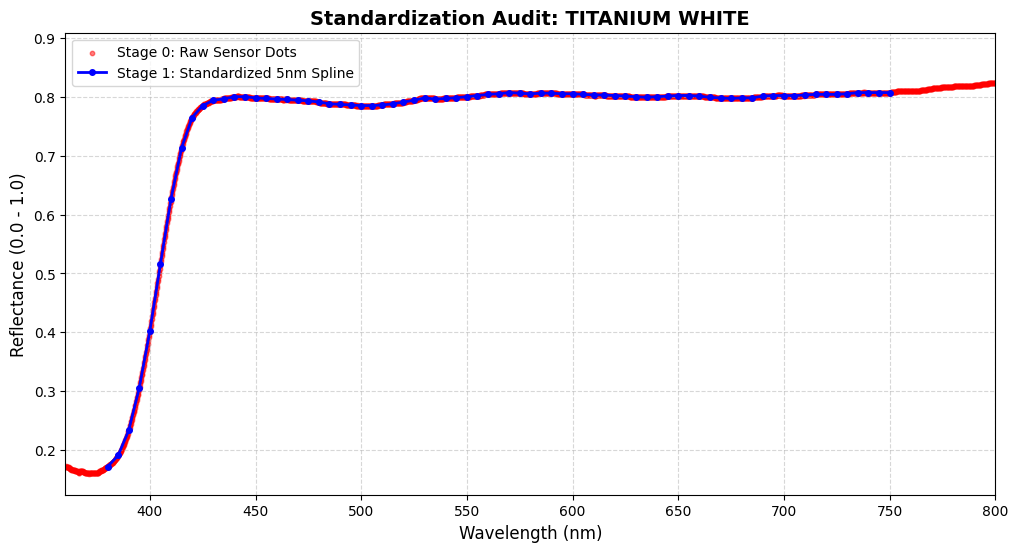

In [123]:
import matplotlib.pyplot as plt

def visualize_standardization_quality(stage0_list, stage1_list, pigment_name="titanium white"):
    """
    PURPOSE: Overlays Raw (Stage 0) vs Standardized (Stage 1) to check for data loss.
    SCIENCE: The Stage 1 curve should be a smooth, continuous line that 
             passes exactly through the Stage 0 'dots'.
    """
    # 1. Find the pigment in both datasets
    p0 = next((p for p in stage0_list if pigment_name in p['name'].lower()), None)
    p1 = next((p for p in stage1_list if pigment_name in p['name'].lower()), None)
    
    if not p0 or not p1:
        print(f"❌ Pigment '{pigment_name}' not found. Check spelling!")
        return

    # 2. Extract arrays
    w0, r0 = np.array(p0['wavelengths']), np.array(p0['reflectance']) / 100.0
    w1, r1 = np.array(p1['wavelengths']), np.array(p1['reflectance'])

    # 3. Create the Plot
    plt.figure(figsize=(12, 6))
    
    # Plot the original sensor data as dots (The 'Truth')
    plt.scatter(w0, r0, color='red', s=10, alpha=0.5, label='Stage 0: Raw Sensor Dots')
    
    # Plot our new standardized 5nm grid as a solid line (The 'Model')
    plt.plot(w1, r1, color='blue', linewidth=2, label='Stage 1: Standardized 5nm Spline', marker='o', markersize=4)

    # Formatting
    plt.title(f"Standardization Audit: {p1['name'].upper()}", fontsize=14, fontweight='bold')
    plt.xlabel("Wavelength (nm)", fontsize=12)
    plt.ylabel("Reflectance (0.0 - 1.0)", fontsize=12)
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.legend()
    
    # Zoom in on a specific part to see the 'Smoothness'
    plt.xlim(360, 800) 
    
    plt.show()

# --- RUN THE AUDIT ---
# Using 'titanium white' as it usually has the most complex curves
visualize_standardization_quality(stage0_data, stage1_data, "titanium white")


In [173]:
import os
import json
import numpy as np
from scipy.optimize import brentq

# Paths
INPUT_STAGE1 = './spectral_pipeline_output/stage1_standardized_data.json'
OUTPUT_DIR = './spectral_pipeline_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)


# --- KM formulas ---
def reflectance_to_K_over_S(R):
    R = np.clip(R, 1e-6, 1.0)
    return ((1 - R)**2) / (2 * R)


def KS_to_Rinf(KS):
    return 1 + KS - np.sqrt(KS**2 + 2 * KS)


# --- Choose target masstone reflectance based on brightness ---
def choose_target_reflectance(R_meas):
    avg = np.mean(R_meas)

    if avg < 0.15:      # blacks, deep blues, deep greens
        return 0.03
    elif avg < 0.30:    # umbers, siennas, dark reds
        return 0.15
    elif avg < 0.60:    # midtones
        return 0.40
    elif avg < 0.80:    # bright yellows, oranges
        return 0.70
    else:               # whites
        return 0.90


# --- Solve for thickness multiplier ---
def find_thickness_factor(KS_meas, R_target):
    def f(t):
        KS_scaled = KS_meas * t
        R_inf = KS_to_Rinf(KS_scaled)
        return np.mean(R_inf) - R_target

    # Search between t=0.1 and t=2000
    return brentq(f, 0.1, 2000)


# --- Stage 2 main ---
def stage2_compute_KS(stage1_path, output_dir):
    with open(stage1_path, 'r') as f:
        stage1_data = json.load(f)

    output_library = []

    for p in stage1_data:
        R_meas = np.array(p["reflectance"])
        KS_meas = reflectance_to_K_over_S(R_meas)

        # pick target masstone reflectance
        R_target = choose_target_reflectance(R_meas)

        # compute per-pigment thickness factor
        t = find_thickness_factor(KS_meas, R_target)

        KS_corrected = KS_meas * t

        output_library.append({
            "index": p["index"],
            "name": p["name"],
            "wavelengths": p["wavelengths"],
            "K_over_S": KS_corrected.tolist(),
            "thickness_factor": t,
            "target_reflectance": R_target
        })

    # Save Stage 2 JSON
    json_path = os.path.join(output_dir, "stage2_K_over_S_pigments.json")
    with open(json_path, 'w') as f:
        json.dump(output_library, f, indent=4)

    print(f"✅ Stage 2 Complete: {len(output_library)} pigments converted to K/S with per-pigment thickness correction.")
    return output_library


# --- RUN ---
stage2_data = stage2_compute_KS(INPUT_STAGE1, OUTPUT_DIR)

✅ Stage 2 Complete: 81 pigments converted to K/S with per-pigment thickness correction.


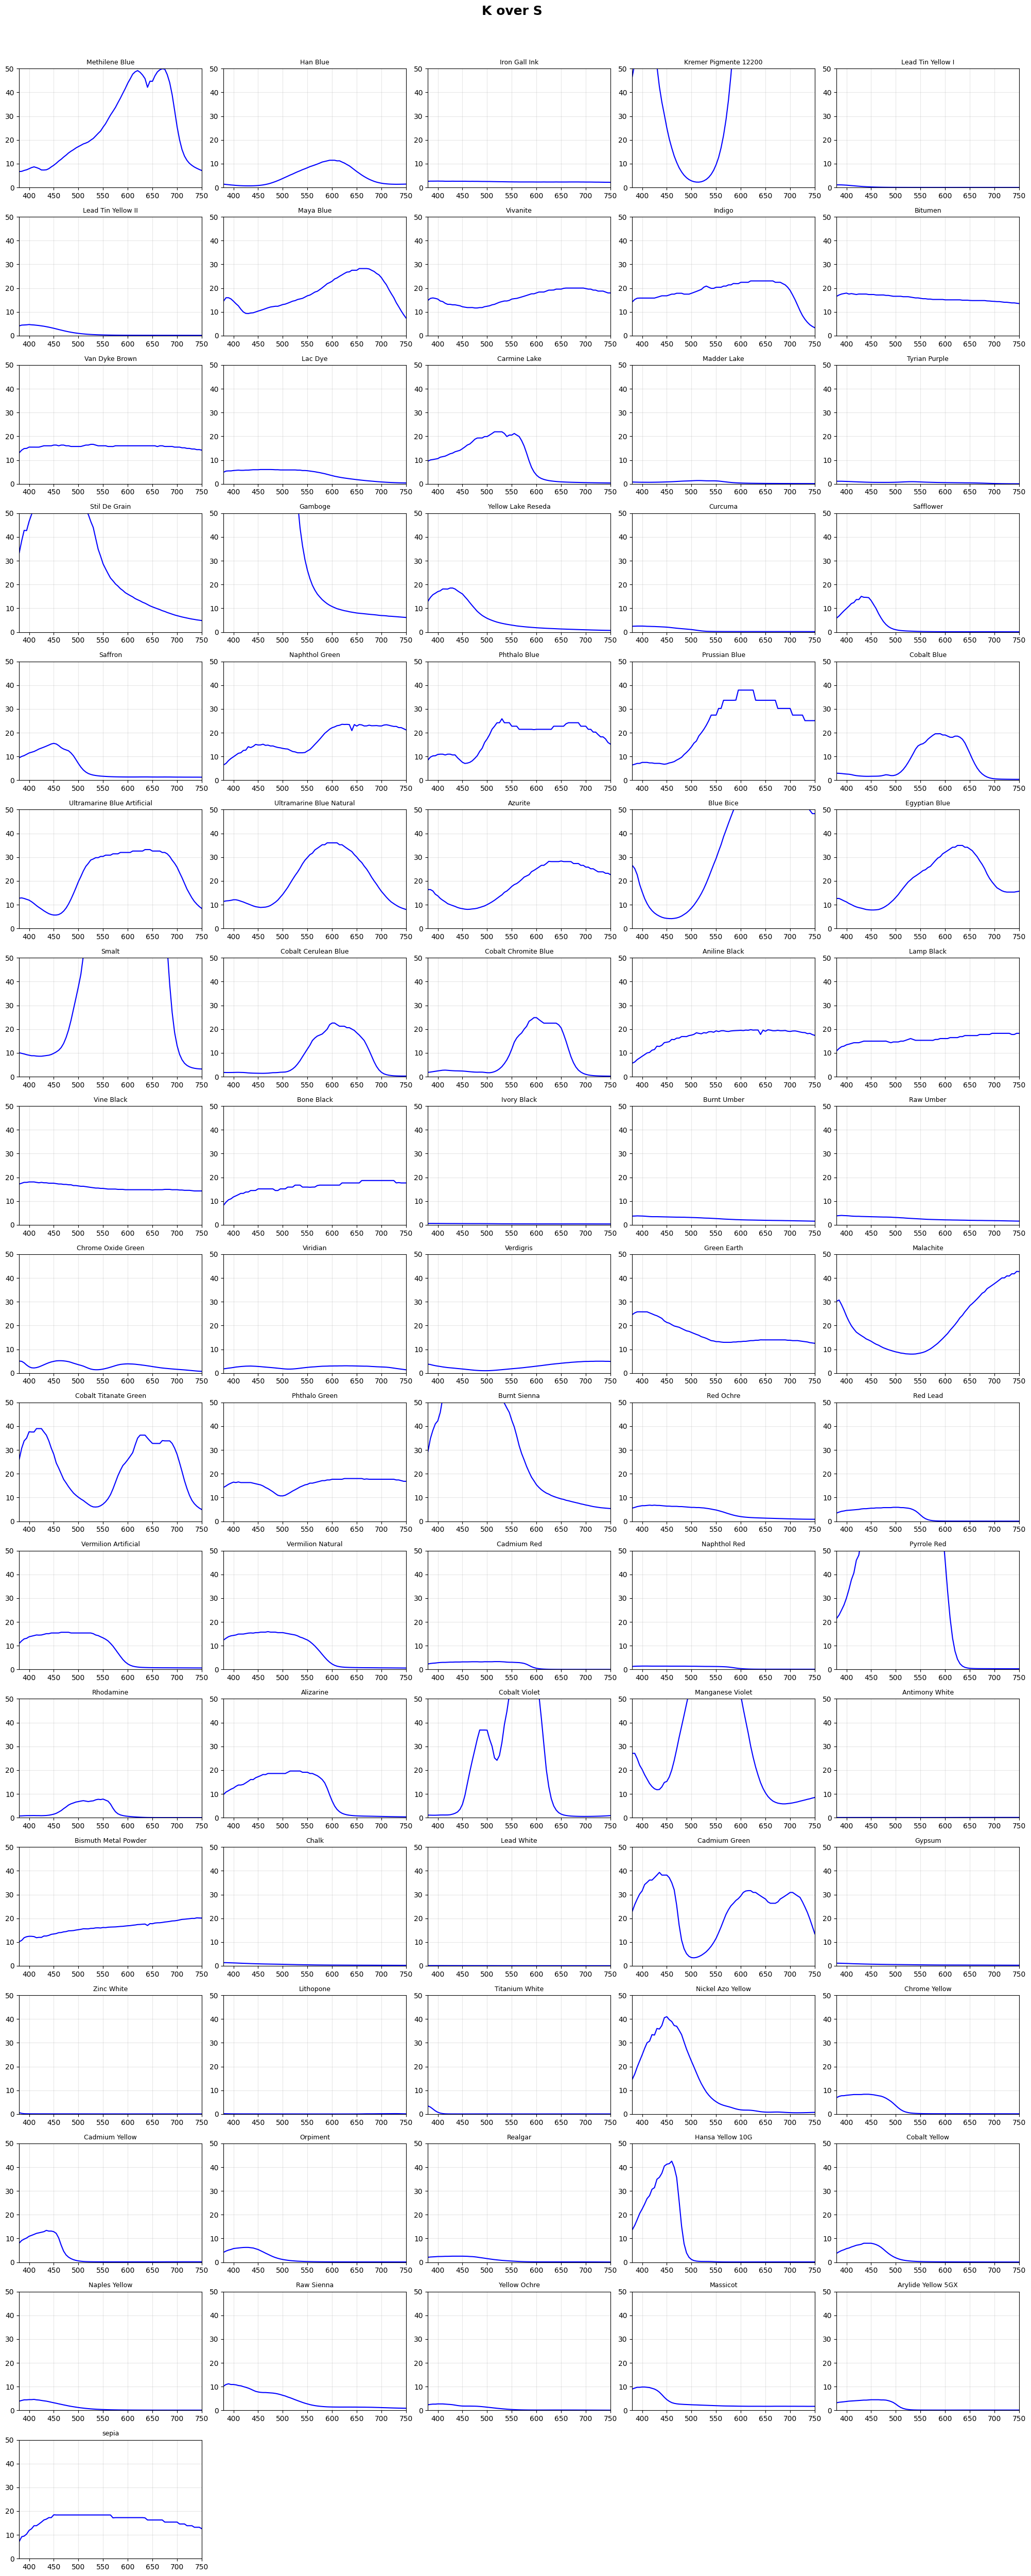

In [174]:
import json
import numpy as np
import matplotlib.pyplot as plt
import math

def visualize_K_over_S_grid(json_path, title="K over S"):
    """
    PURPOSE:
        Displays a grid of reflectance curves for all pigments in a JSON file.
        Useful for visually auditing Stage 0, Stage 1, or later stages.

    INPUT:
        json_path : path to a stage JSON file (e.g., stage1_standardized_data.json)

    BEHAVIOR:
        - Creates a grid of subplots
        - Each subplot shows one pigment's reflectance curve
        - Automatically adjusts grid size based on pigment count
    """

    # --- Load JSON ---
    with open(json_path, 'r') as f:
        data = json.load(f)

    n = len(data)
    cols = 5
    rows = math.ceil(n / cols)

    plt.figure(figsize=(cols * 4, rows * 3))
    plt.suptitle(title, fontsize=18, fontweight='bold')

    for i, pigment in enumerate(data):
        w = np.array(pigment["wavelengths"])
        r = np.array(pigment["K_over_S"])

        ax = plt.subplot(rows, cols, i + 1)
        ax.plot(w, r, color="blue", linewidth=1.5)

        ax.set_title(pigment["name"], fontsize=9)
        ax.set_ylim(0, 50)
        ax.set_xlim(w.min(), w.max())
        ax.grid(True, alpha=0.3)

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

visualize_K_over_S_grid("./spectral_pipeline_output/stage2_K_over_S_pigments.json")


=== Comparison at 450 nm ===

Pigment: Titanium White
  Nearest wavelength: 450 nm
  Reflectance R ≈ 0.3781
  K/S ≈ 0.5113
  → Moderate absorption

Pigment: Ivory Black
  Nearest wavelength: 450 nm
  Reflectance R ≈ 0.0299
  K/S ≈ 15.7402
  → Strong absorption at this wavelength

Pigment: Cadmium Yellow
  Nearest wavelength: 450 nm
  Reflectance R ≈ 0.0032
  K/S ≈ 153.0068
  → Strong absorption at this wavelength

Pigment: Ultramarine Blue Artificial
  Nearest wavelength: 450 nm
  Reflectance R ≈ 0.0192
  K/S ≈ 25.0750
  → Strong absorption at this wavelength


=== Comparison at 600 nm ===

Pigment: Titanium White
  Nearest wavelength: 600 nm
  Reflectance R ≈ 0.3917
  K/S ≈ 0.4724
  → Moderate absorption

Pigment: Ivory Black
  Nearest wavelength: 600 nm
  Reflectance R ≈ 0.0383
  K/S ≈ 12.0714
  → Strong absorption at this wavelength

Pigment: Cadmium Yellow
  Nearest wavelength: 600 nm
  Reflectance R ≈ 0.1807
  K/S ≈ 1.8574
  → Strong absorption at this wavelength

Pigment: Ultram

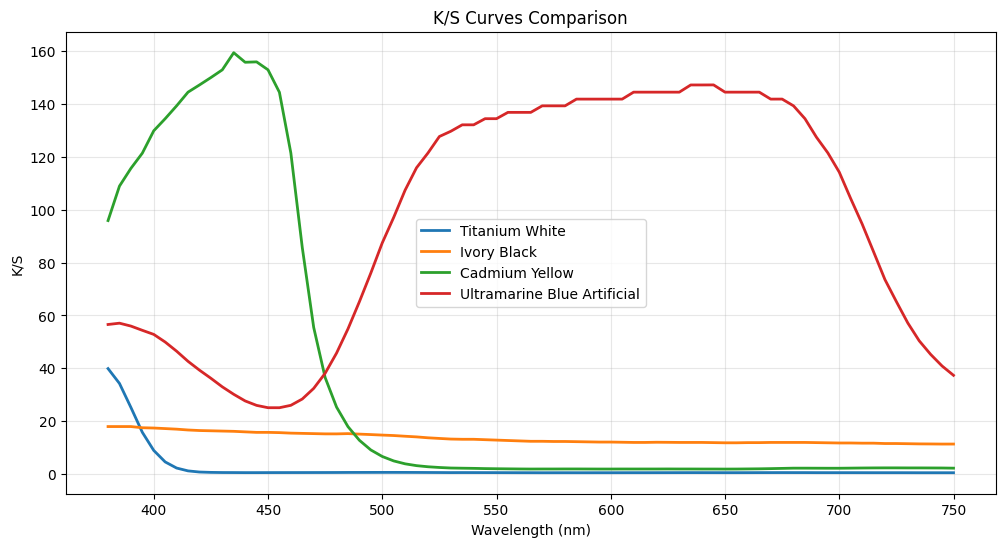

In [169]:
import json
import numpy as np
import matplotlib.pyplot as plt

STAGE2_JSON = "./spectral_pipeline_output/stage2_K_over_S_pigments.json"

# Load Stage 2 data
with open(STAGE2_JSON, "r") as f:
    pigments = json.load(f)

# Build lookup by name (case-insensitive)
pigment_dict = {p["name"].lower(): p for p in pigments}

def get_pigment(name):
    name = name.lower()
    matches = [p for p in pigments if name in p["name"].lower()]
    if not matches:
        raise ValueError(f"Pigment '{name}' not found.")
    return matches[0]

def compare_at_wavelength(pigment_names, wavelength):
    """
    Print reflectance and K/S for selected pigments at a given wavelength.
    """
    print(f"\n=== Comparison at {wavelength} nm ===\n")

    for name in pigment_names:
        p = get_pigment(name)
        w = np.array(p["wavelengths"])
        ks = np.array(p["K_over_S"])

        # Find nearest wavelength index
        idx = np.argmin(np.abs(w - wavelength))

        # Reconstruct reflectance from K/S for interpretation:
        # R = 1 + K/S - sqrt((K/S)^2 + 2*K/S)
        K_over_S = ks[idx]
        R = 1 + K_over_S - np.sqrt(K_over_S**2 + 2*K_over_S)

        print(f"Pigment: {p['name']}")
        print(f"  Nearest wavelength: {w[idx]} nm")
        print(f"  Reflectance R ≈ {R:.4f}")
        print(f"  K/S ≈ {K_over_S:.4f}")

        # Interpretation
        if K_over_S < 0.1:
            meaning = "→ Very low absorption (high reflectance)"
        elif K_over_S < 1:
            meaning = "→ Moderate absorption"
        else:
            meaning = "→ Strong absorption at this wavelength"

        print(f"  {meaning}\n")


def plot_KS_curves(pigment_names):
    """
    Plot full K/S curves for selected pigments.
    """
    plt.figure(figsize=(12, 6))

    for name in pigment_names:
        p = get_pigment(name)
        w = np.array(p["wavelengths"])
        ks = np.array(p["K_over_S"])
        plt.plot(w, ks, label=p["name"], linewidth=2)

    plt.title("K/S Curves Comparison")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("K/S")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


# --- Example usage ---
pigments_to_compare = ["titanium white", "ivory black", "cadmium yellow", "ultramarine blue"]

compare_at_wavelength(pigments_to_compare, 450)   # blue region
compare_at_wavelength(pigments_to_compare, 600)   # red region

plot_KS_curves(pigments_to_compare)

✅ Stage 3 Complete: 81 pigments with reconstructed reflectance.


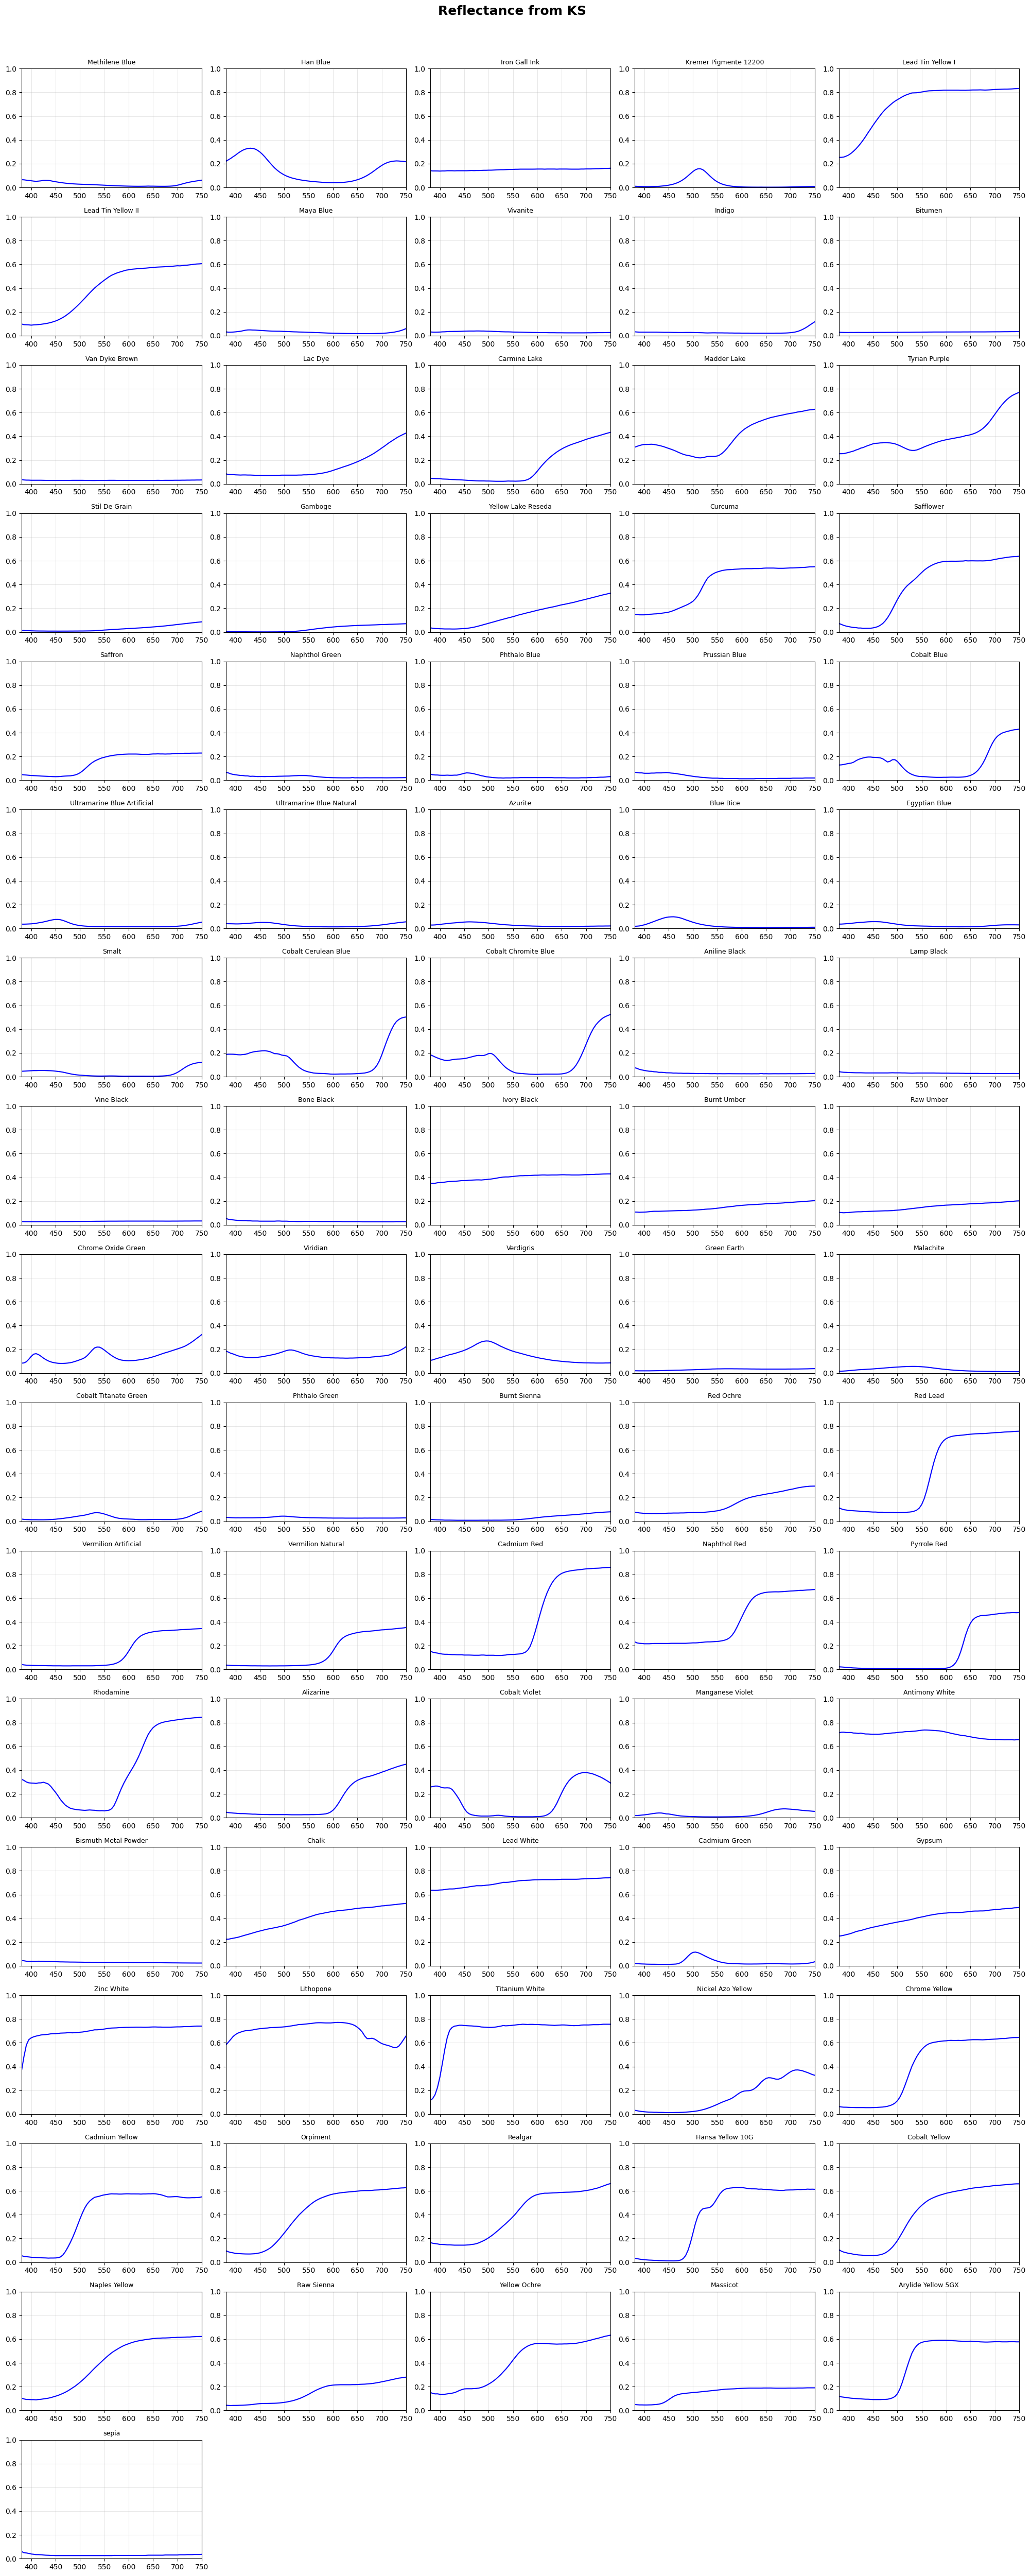

In [175]:
import os
import json
import numpy as np

# Paths
INPUT_STAGE2 = './spectral_pipeline_output/stage2_K_over_S_pigments.json'
OUTPUT_DIR = './spectral_pipeline_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)


def KS_to_reflectance_infinite(KS):
    """
    Kubelka–Munk infinite-thickness reflectance from K/S:

        R_inf = 1 + K/S - sqrt((K/S)^2 + 2*K/S)

    This assumes an optically thick (masstone) layer.
    """
    KS = np.clip(KS, 0, None)
    return 1 + KS - np.sqrt(KS**2 + 2 * KS)


def stage3_reconstruct_reflectance(stage2_path, output_dir):
    """
    PURPOSE:
        Convert Stage 2 K/S curves into reflectance curves (masstone).

    INPUT:
        - Stage 2 JSON containing:
            index, name, wavelengths, K_over_S

    OUTPUT JSON FORMAT:
        [
            {
                "index": "...",
                "name": "...",
                "wavelengths": [...],
                "K_over_S": [...],
                "reflectance": [...]
            },
            ...
        ]
    """
    with open(stage2_path, 'r') as f:
        stage2_data = json.load(f)

    output_library = []

    for p in stage2_data:
        KS = np.array(p["K_over_S"])
        R_inf = KS_to_reflectance_infinite(KS)

        output_library.append({
            "index": p["index"],
            "name": p["name"],
            "wavelengths": p["wavelengths"],
            "K_over_S": KS.tolist(),
            "reflectance": R_inf.tolist()
        })

    json_path = os.path.join(output_dir, "stage3_reflectance_from_KS.json")
    with open(json_path, 'w') as f:
        json.dump(output_library, f, indent=4)

    print(f"✅ Stage 3 Complete: {len(output_library)} pigments with reconstructed reflectance.")
    return output_library


# --- RUN ---
stage3_data = stage3_reconstruct_reflectance(INPUT_STAGE2, OUTPUT_DIR)

visualize_pigment_grid("./spectral_pipeline_output/stage3_reflectance_from_KS.json",
                       title="Reflectance from KS")

In [177]:
import json
import numpy as np
import colour

STAGE3_JSON = "./spectral_pipeline_output/stage3_reflectance_from_KS.json"

def spectrum_to_xyz(wavelengths, reflectance):
    """
    Convert reflectance spectrum to XYZ using colour-science.
    """
    w = np.array(wavelengths)
    R = np.array(reflectance)

    # Build a SpectralDistribution object
    sd = colour.SpectralDistribution(
        data=dict(zip(w, R)),
        name="pigment"
    )

    # Convert to XYZ under D65
    XYZ = colour.sd_to_XYZ(sd, illuminant=colour.SDS_ILLUMINANTS["D65"])
    return XYZ


def xyz_to_srgb(XYZ):
    """
    Convert XYZ to sRGB using colour-science.
    """
    # NORMALIZE to 0–1 before conversion
    XYZ_norm = XYZ / 100.0
    
    # Convert XYZ to sRGB (linear → gamma corrected)
    rgb = colour.XYZ_to_sRGB(XYZ_norm)

    # Clip to displayable range
    rgb = np.clip(rgb, 0, 1)
    return rgb

def stage3_to_srgb(stage3_path):
    with open(stage3_path, "r") as f:
        pigments = json.load(f)

    for p in pigments:
        w = p["wavelengths"]
        R = p["reflectance"]

        XYZ = spectrum_to_xyz(w, R)
        sRGB = xyz_to_srgb(XYZ)

        p["XYZ"] = XYZ.tolist()
        p["sRGB"] = sRGB.tolist()

    out_path = "./spectral_pipeline_output/stage3_with_sRGB.json"
    with open(out_path, "w") as f:
        json.dump(pigments, f, indent=4)

    print("🎨 Stage 3.5 Complete — sRGB values added.")
    return pigments


# --- RUN ---
pigments_with_srgb = stage3_to_srgb(STAGE3_JSON)

p = pigments_with_srgb[37]
print(p["name"])
print(p["wavelengths"])
print(p["reflectance"])


🎨 Stage 3.5 Complete — sRGB values added.
Ivory Black
[380, 385, 390, 395, 400, 405, 410, 415, 420, 425, 430, 435, 440, 445, 450, 455, 460, 465, 470, 475, 480, 485, 490, 495, 500, 505, 510, 515, 520, 525, 530, 535, 540, 545, 550, 555, 560, 565, 570, 575, 580, 585, 590, 595, 600, 605, 610, 615, 620, 625, 630, 635, 640, 645, 650, 655, 660, 665, 670, 675, 680, 685, 690, 695, 700, 705, 710, 715, 720, 725, 730, 735, 740, 745, 750]
[0.3501151858675067, 0.35009579124631585, 0.35011463996750636, 0.3543683283092043, 0.35541194826917466, 0.357476969141584, 0.35965002392533685, 0.362811584396586, 0.3649206995883332, 0.36594223156262995, 0.36702381770238923, 0.36807488746289874, 0.37019957529342884, 0.37227160926134073, 0.3722644642953181, 0.3733159646732036, 0.3754081562771223, 0.3764524141037009, 0.37749649178786004, 0.3785398737039709, 0.3786114535688454, 0.3774971038427517, 0.3795826484617528, 0.38155831315887534, 0.3837717077783147, 0.3857951864395748, 0.388958294034907, 0.391939265816458, 0.

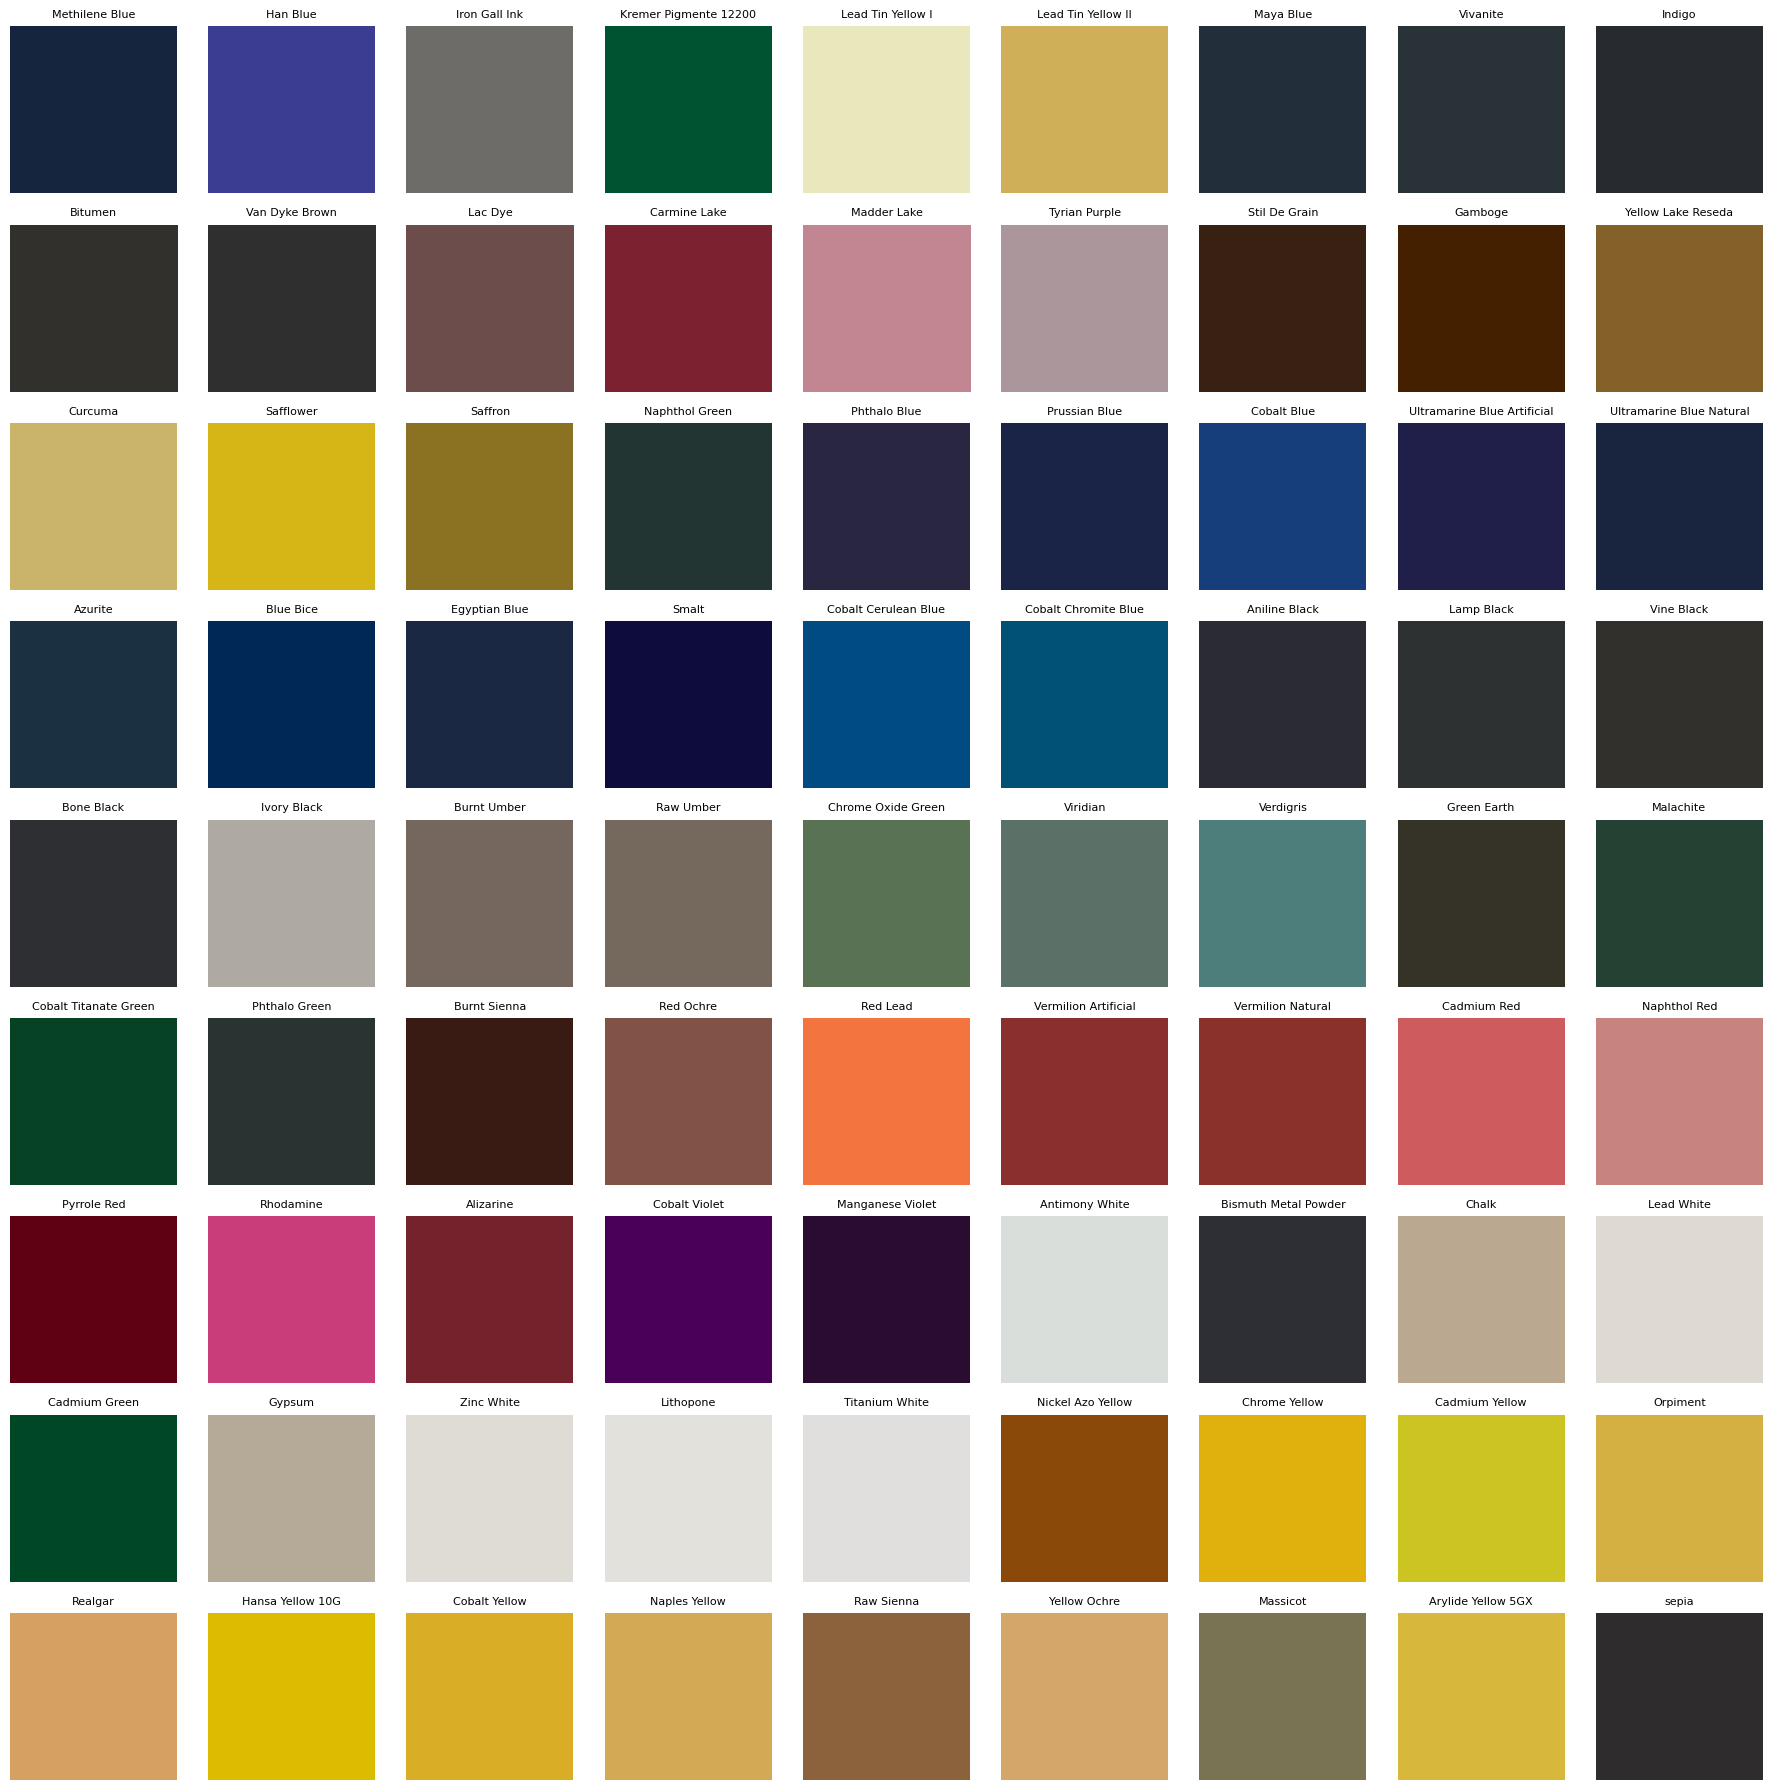

In [178]:
import json
import numpy as np
import matplotlib.pyplot as plt

INPUT = "./spectral_pipeline_output/stage3_with_sRGB.json"

# Load pigments with sRGB
with open(INPUT, "r") as f:
    pigments = json.load(f)

names = [p["name"] for p in pigments]
colors = [p["sRGB"] for p in pigments]

# Convert 0–1 floats → 0–255 ints
colors_255 = [(np.array(rgb) * 255).astype(np.uint8) for rgb in colors]

# Grid size
n = len(colors_255)
cols = int(np.ceil(np.sqrt(n)))
rows = int(np.ceil(n / cols))

fig, ax = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
ax = ax.flatten()

for i, (name, rgb) in enumerate(zip(names, colors_255)):
    # Matplotlib expects 0–1 floats, so convert back for display
    rgb_float = rgb / 255.0
    ax[i].imshow([[rgb_float]])
    ax[i].set_title(name, fontsize=8)
    ax[i].axis("off")

# Hide unused cells
for j in range(i + 1, len(ax)):
    ax[j].axis("off")

plt.tight_layout()
plt.show()

In [179]:
import json
import numpy as np
import colour

with open("./spectral_pipeline_output/stage1_standardized_data.json", "r") as f:
    stage1 = json.load(f)

def spectrum_to_xyz_from_stage1(wavelengths, R):
    sd = colour.SpectralDistribution(dict(zip(wavelengths, R)), name="pigment")
    XYZ = colour.sd_to_XYZ(sd, illuminant=colour.SDS_ILLUMINANTS["D65"])
    return XYZ

def xyz_to_srgb(XYZ):
    XYZ_norm = XYZ / 100.0
    rgb = colour.XYZ_to_sRGB(XYZ_norm)
    return np.clip(rgb, 0, 1)

# pick Ivory Black from Stage 1
p = next(p for p in stage1 if "Ivory Black" in p["name"])
w = p["wavelengths"]
R = p["reflectance"]

XYZ = spectrum_to_xyz_from_stage1(w, R)
rgb = xyz_to_srgb(XYZ)

print(p["name"], "Stage 1 sRGB:", rgb)

Ivory Black Stage 1 sRGB: [ 0.63358004  0.61537088  0.58612806]


In [82]:
import json
import numpy as np
import colour
import os

# Paths
INPUT_JSON = './spectral_pipeline_output/stage1_standardized_data.json'
OUTPUT_DIR = './spectral_pipeline_output'

def stage2_calibrate_library(input_path, output_path, target_y=95.0):
    """
    PURPOSE: Calibrates the library so White looks like Artist-Grade White.
    SCIENCE: Uses CIE 1931 Luminance (Y) to find the 'Master Scale Factor'.
    """
    with open(input_path, 'r') as f:
        library = json.load(f)
    
    # 1. Setup CIE 1931 Environment
    # Standard Observer (The Human Eye) and D65 (Daylight)
    cmfs = colour.MSDS_CMFS['CIE 1931 2 Degree Standard Observer']
    illuminant = colour.SDS_ILLUMINANTS['D65']
    
    # 2. Find the Anchor: Titanium White
    # We look for 'titanium white' in the name
    white_entry = next((p for p in library if "titanium white" in p['name'].lower()), None)
    
    if not white_entry:
        print("❌ Error: 'titanium white' not found in Stage 1 JSON. Calibration failed.")
        return
    
    # 3. Calculate current Luminance (Y) of the White
    w_wavelengths = np.array(white_entry['wavelengths'])
    w_reflectance = np.array(white_entry['reflectance'])

    mask = (w_wavelengths >= 360) & (w_wavelengths <= 700)
    w_vis, r_vis = w_wavelengths[mask], w_reflectance[mask]
    
    sd_white = colour.SpectralDistribution(dict(zip(w_vis, r_vis)))
    # We must align the CMFs to our 5nm grid for the math to work
    xyz_white = colour.sd_to_XYZ(sd_white, cmfs, illuminant, method='Integration')
    
    current_y = xyz_white[1] # XYZ index 1 is 'Y' (Luminance)
    
    # 4. Calculate the 'Master Scale Factor'
    scale_factor = target_y / current_y
    print(f"📊 Titanium White current Y: {round(current_y, 2)}")
    print(f"🚀 Calibration Factor: {round(scale_factor, 3)}x")

    # 5. Apply the Scale Factor to EVERY pigment in the library
    calibrated_library = []
    for p in library:
        refl_calibrated = np.array(p['reflectance']) * scale_factor
        # Safety Clip: Ensure no pigment reflects more than 100.1% light
        refl_calibrated = np.clip(refl_calibrated, 0.0, 1.0)
        
        p_calibrated = p.copy()
        p_calibrated['reflectance'] = refl_calibrated.tolist()
        # Store the scale factor used (good for debugging)
        p_calibrated['calibration_factor'] = scale_factor
        
        calibrated_library.append(p_calibrated)

    # 6. Save to Stage 2 JSON
    output_filename = os.path.join(output_path, "stage2_calibrated_data.json")
    with open(output_filename, 'w') as f:
        json.dump(calibrated_library, f, indent=4)
    
    print(f"✅ Stage 2 Complete: Library calibrated and saved to {output_filename}")
    return calibrated_library

# --- RUN ---
stage2_data = stage2_calibrate_library(INPUT_JSON, OUTPUT_DIR)


📊 Titanium White current Y: 79.92
🚀 Calibration Factor: 1.189x
✅ Stage 2 Complete: Library calibrated and saved to ./spectral_pipeline_output\stage2_calibrated_data.json


In [153]:
def test_stage2_calibration(data_list):
    white = next((p for p in data_list if "titanium white" in p['name'].lower()), None)
    
    # Re-calculate Y
    sd = colour.SpectralDistribution(dict(zip(white['wavelengths'], white['reflectance'])))
    cmfs = colour.MSDS_CMFS['CIE 1931 2 Degree Standard Observer']
    illuminant = colour.SDS_ILLUMINANTS['D65']
    y_final = colour.sd_to_XYZ(sd, cmfs, illuminant, method='Integration')[1]
    
    print(f"🎯 Calibrated Titanium White Y: {round(y_final, 2)}")
    assert np.isclose(y_final, 95.0, atol=0.1)
    print("✅ Calibration is Perfect!")

test_stage2_calibration(stage2_data)


KeyError: 'reflectance'

❌ Error: 'NA_Acrylic_Binder' not found in Stage 2 JSON.


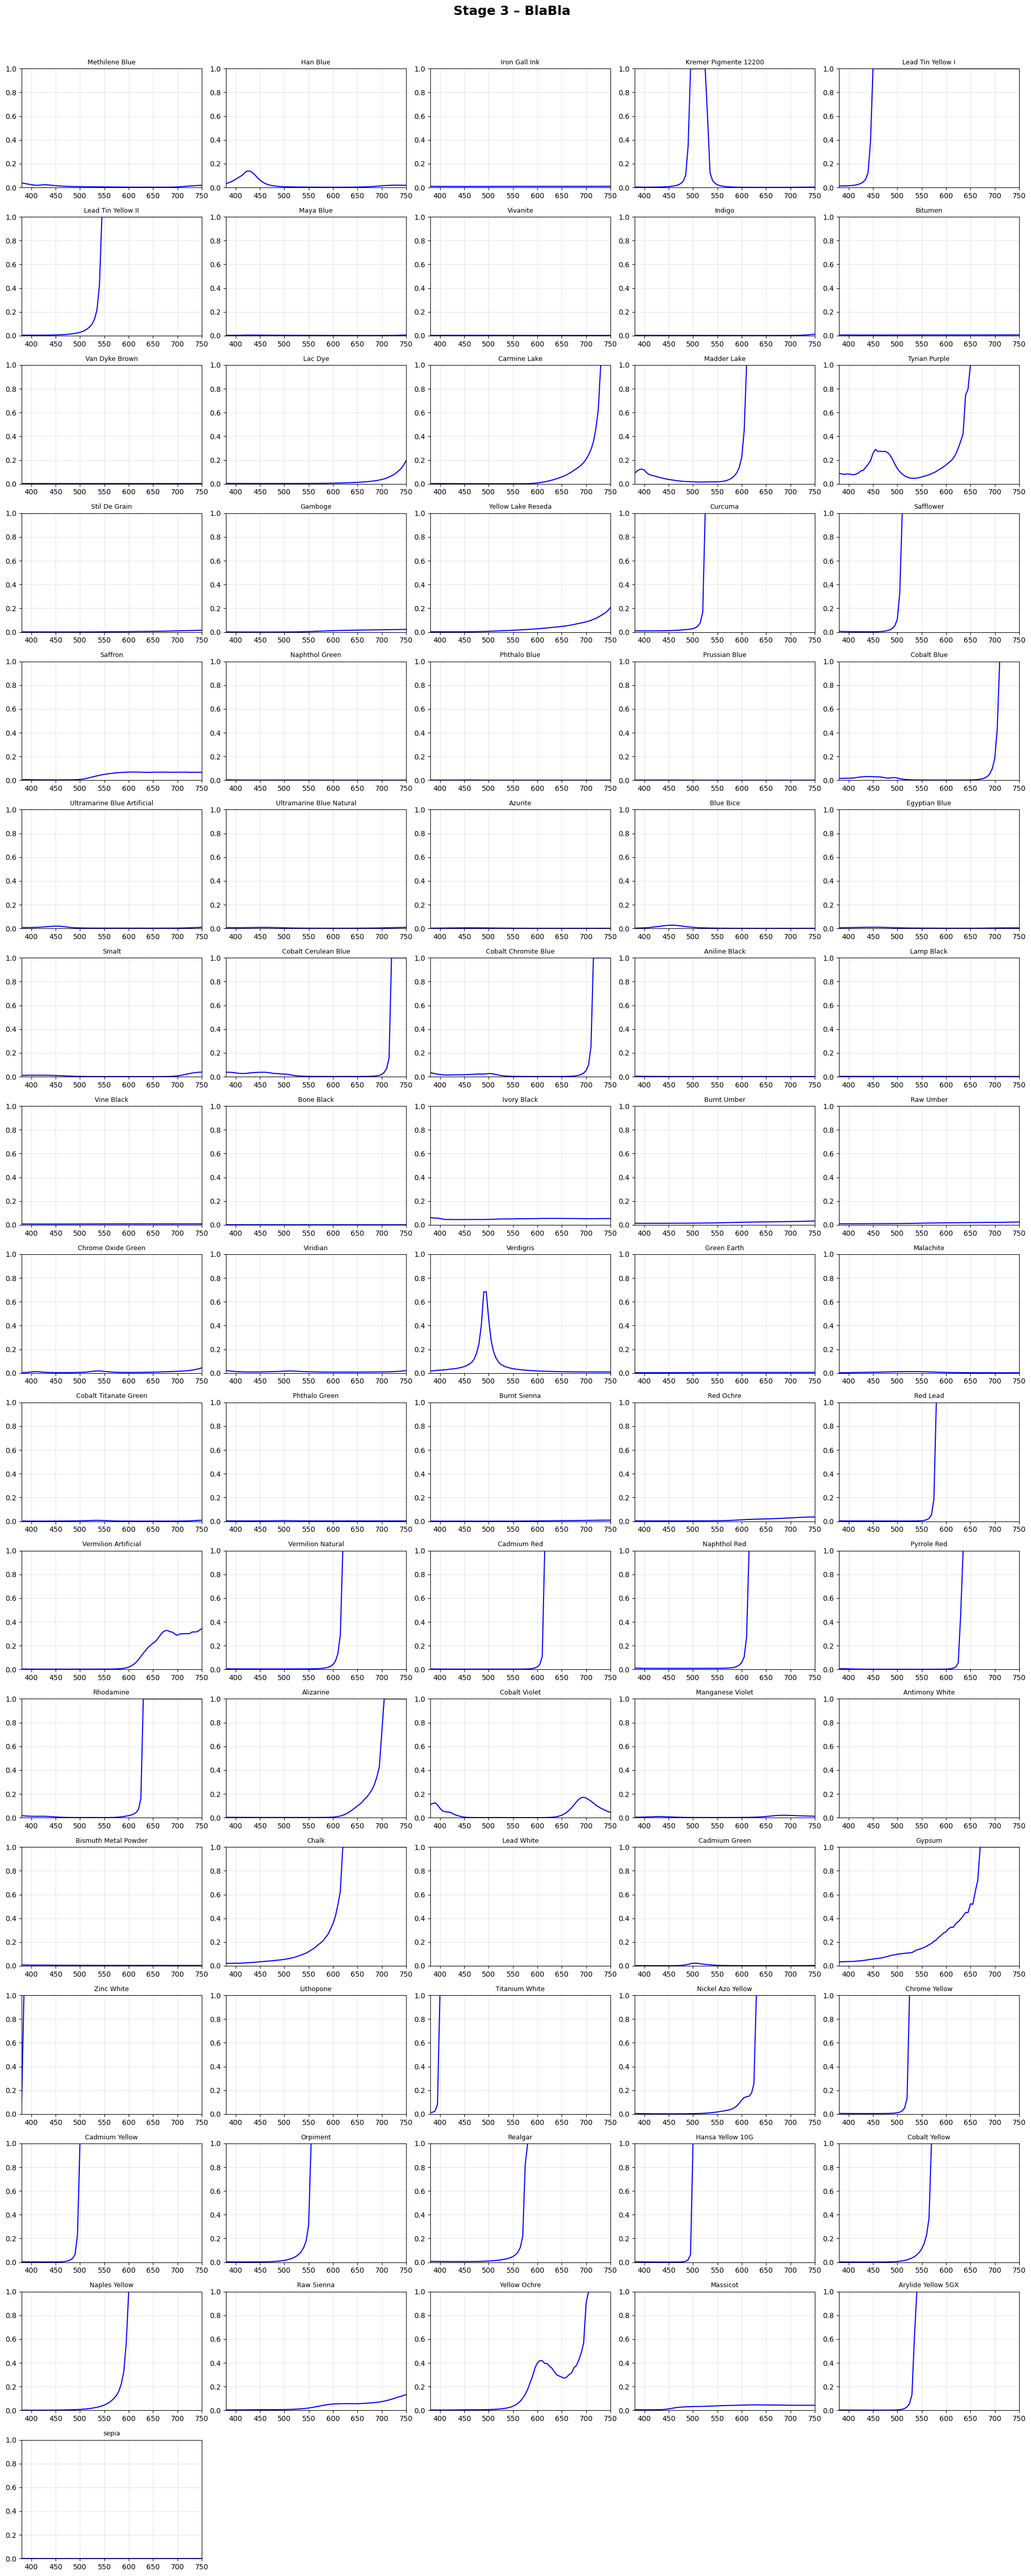

In [154]:
import json
import numpy as np
import os

# Paths
INPUT_JSON = './spectral_pipeline_output/stage1_standardized_data.json'
OUTPUT_DIR = './spectral_pipeline_output'

def stage3_physics_transformation(input_path, output_path, concentration=30.0):
    """
    PURPOSE: Extracts 'Pure Pigment DNA' and simulates 'Infinite Thickness' (Masstone).
    SCIENCE: 
        1. Convert R to K/S (Absorption/Scattering ratio).
        2. Subtract the Acrylic Binder's absorption contribution.
        3. Simulate high concentration (Tube Paint) to remove White Card interference.
    """
    with open(input_path, 'r') as f:
        library = json.load(f)
    
    # 1. Isolate the Binder Reference
    binder_entry = next((p for p in library if "acrylic binder" in p['name'].lower()), None)
    if not binder_entry:
        print("❌ Error: 'NA_Acrylic_Binder' not found in Stage 2 JSON.")
        return

    # Convert Binder R to K/S (This is the 'noise' we want to remove)
    r_binder = np.array(binder_entry['reflectance'])
    ks_binder = ((1 - r_binder)**2) / (2 * r_binder + 1e-7)

    physics_library = []
    
    for p in library:
        # We don't process the binder itself as a pigment
        if "acrylic binder" in p['name'].lower():
            continue
            
        try:
            r_mix = np.array(p['reflectance'])
            
            # 2. CONVERT TO K/S (Total Absorption of Pigment + Binder + Card interference)
            ks_total = ((1 - r_mix)**2) / (2 * r_mix + 1e-7)
            
            # 3. SUBTRACT BINDER (Isolate the Pigment particles)
            # We assume a standard volume fraction where binder is the majority
            ks_pigment_only = np.maximum(ks_total - ks_binder, 0)
            
            # 4. SIMULATE MASSTONE (Infinite Thickness)
            # Multiplying by 'concentration' simulates the light traveling through 
            # so much pigment that it never sees the white card.
            ks_masstone = ks_pigment_only * concentration
            
            # 5. REVERSE K-M (Convert back to Reflectance)
            # Formula: R = 1 + K/S - sqrt( (K/S)^2 + 2*K/S )
            r_deep = 1 + ks_masstone - np.sqrt(ks_masstone**2 + 2 * ks_masstone)
            
            p_physics = p.copy()
            p_physics['reflectance'] = np.clip(r_deep, 0, 1).tolist()
            # We store the K/S 'DNA' for the future mixing engine!
            p_physics['ks_dna'] = ks_pigment_only.tolist()
            
            physics_library.append(p_physics)
            
        except Exception as e:
            print(f"⚠️ Physics error for {p['name']}: {e}")

    # 6. Save to Stage 3 JSON
    output_filename = os.path.join(output_path, "stage3_physics_data.json")
    with open(output_filename, 'w') as f:
        json.dump(physics_library, f, indent=4)
    
    print(f"✅ Stage 3 Complete: {len(physics_library)} pigments transformed to Masstone.")
    return physics_library

# --- RUN ---
stage3_data = stage3_physics_transformation(INPUT_JSON, OUTPUT_DIR)
visualize_pigment_grid("./spectral_pipeline_output/stage3_physics_data.json",
                       title="Stage 3 – BlaBla")


In [85]:
def test_stage3_physics(s2_list, s3_list, pigment_name="phthalo blue"):
    p2 = next((p for p in s2_list if pigment_name in p['name'].lower()), None)
    p3 = next((p for p in s3_list if pigment_name in p['name'].lower()), None)
    
    r2_avg = np.mean(p2['reflectance'])
    r3_avg = np.mean(p3['reflectance'])
    
    print(f"📊 {pigment_name.upper()} Reflectance Shift:")
    print(f"   Stage 2 (Pale/Acrylic): {round(r2_avg, 3)}")
    print(f"   Stage 3 (Deep/Oil):     {round(r3_avg, 3)}")
    
    assert r3_avg < r2_avg, "Physics failed to deepen the color!"
    print("✅ Stage 3 physics successfully removed the 'chalky' look.")

test_stage3_physics(stage2_data, stage3_data)


📊 PHTHALO BLUE Reflectance Shift:
   Stage 2 (Pale/Acrylic): 0.034
   Stage 3 (Deep/Oil):     0.001
✅ Stage 3 physics successfully removed the 'chalky' look.


In [86]:
import json
import numpy as np
import colour
import os
import matplotlib.pyplot as plt

# Paths
INPUT_JSON = './spectral_pipeline_output/stage2_calibrated_data.json'
OUTPUT_DIR = './spectral_pipeline_output'

def stage4_perception_pipeline(input_path, output_path):
    """
    PURPOSE: Converts 'Deep Physics' spectral data into Monitor-Ready RGB.
    SCIENCE: 1. Spectral Integration 2. Illuminant D65 3. XYZ to sRGB
    """
    with open(input_path, 'r') as f:
        library = json.load(f)
    
    cmfs = colour.MSDS_CMFS['CIE 1931 2 Degree Standard Observer']
    illuminant = colour.SDS_ILLUMINANTS['D65']
    
    display_library = []
    
    for p in library:
        try:
            # 1. Load the 'Deep' Reflectance from Stage 3
            w = np.array(p['wavelengths'])
            r = np.array(p['reflectance'])
            
            # 2. Integrate Spectral Distribution to XYZ
            # We ensure the wavelength range is exactly what the CMFs expect
            sd = colour.SpectralDistribution(dict(zip(w, r))).align(colour.SpectralShape(360, 780, 1))
            xyz = colour.sd_to_XYZ(sd, cmfs, illuminant, method='Integration')
            
            # 3. Convert XYZ to sRGB
            rgb = colour.XYZ_to_sRGB(xyz / 100.0)
            rgb_255 = (np.clip(rgb, 0, 1) * 255).astype(int)
            hex_code = '#%02x%02x%02x' % tuple(rgb_255)
            
            # 4. Carry over ALL metadata and add the new RGB/Hex
            p_display = p.copy()
            p_display['rgb'] = rgb_255.tolist()
            p_display['hex'] = hex_code
            
            display_library.append(p_display)
            
        except Exception as e:
            print(f"⚠️ Perception error for {p['name']}: {e}")

    # 5. Save to Stage 4 JSON
    output_filename = os.path.join(output_path, "stage4_display_data.json")
    with open(output_filename, 'w') as f:
        json.dump(display_library, f, indent=4)
    
    print(f"✅ Stage 4 Complete: {len(display_library)} pigment tiles generated.")
    return display_library

# --- RUN ---
stage4_data = stage4_perception_pipeline(INPUT_JSON, OUTPUT_DIR)


✅ Stage 4 Complete: 82 pigment tiles generated.


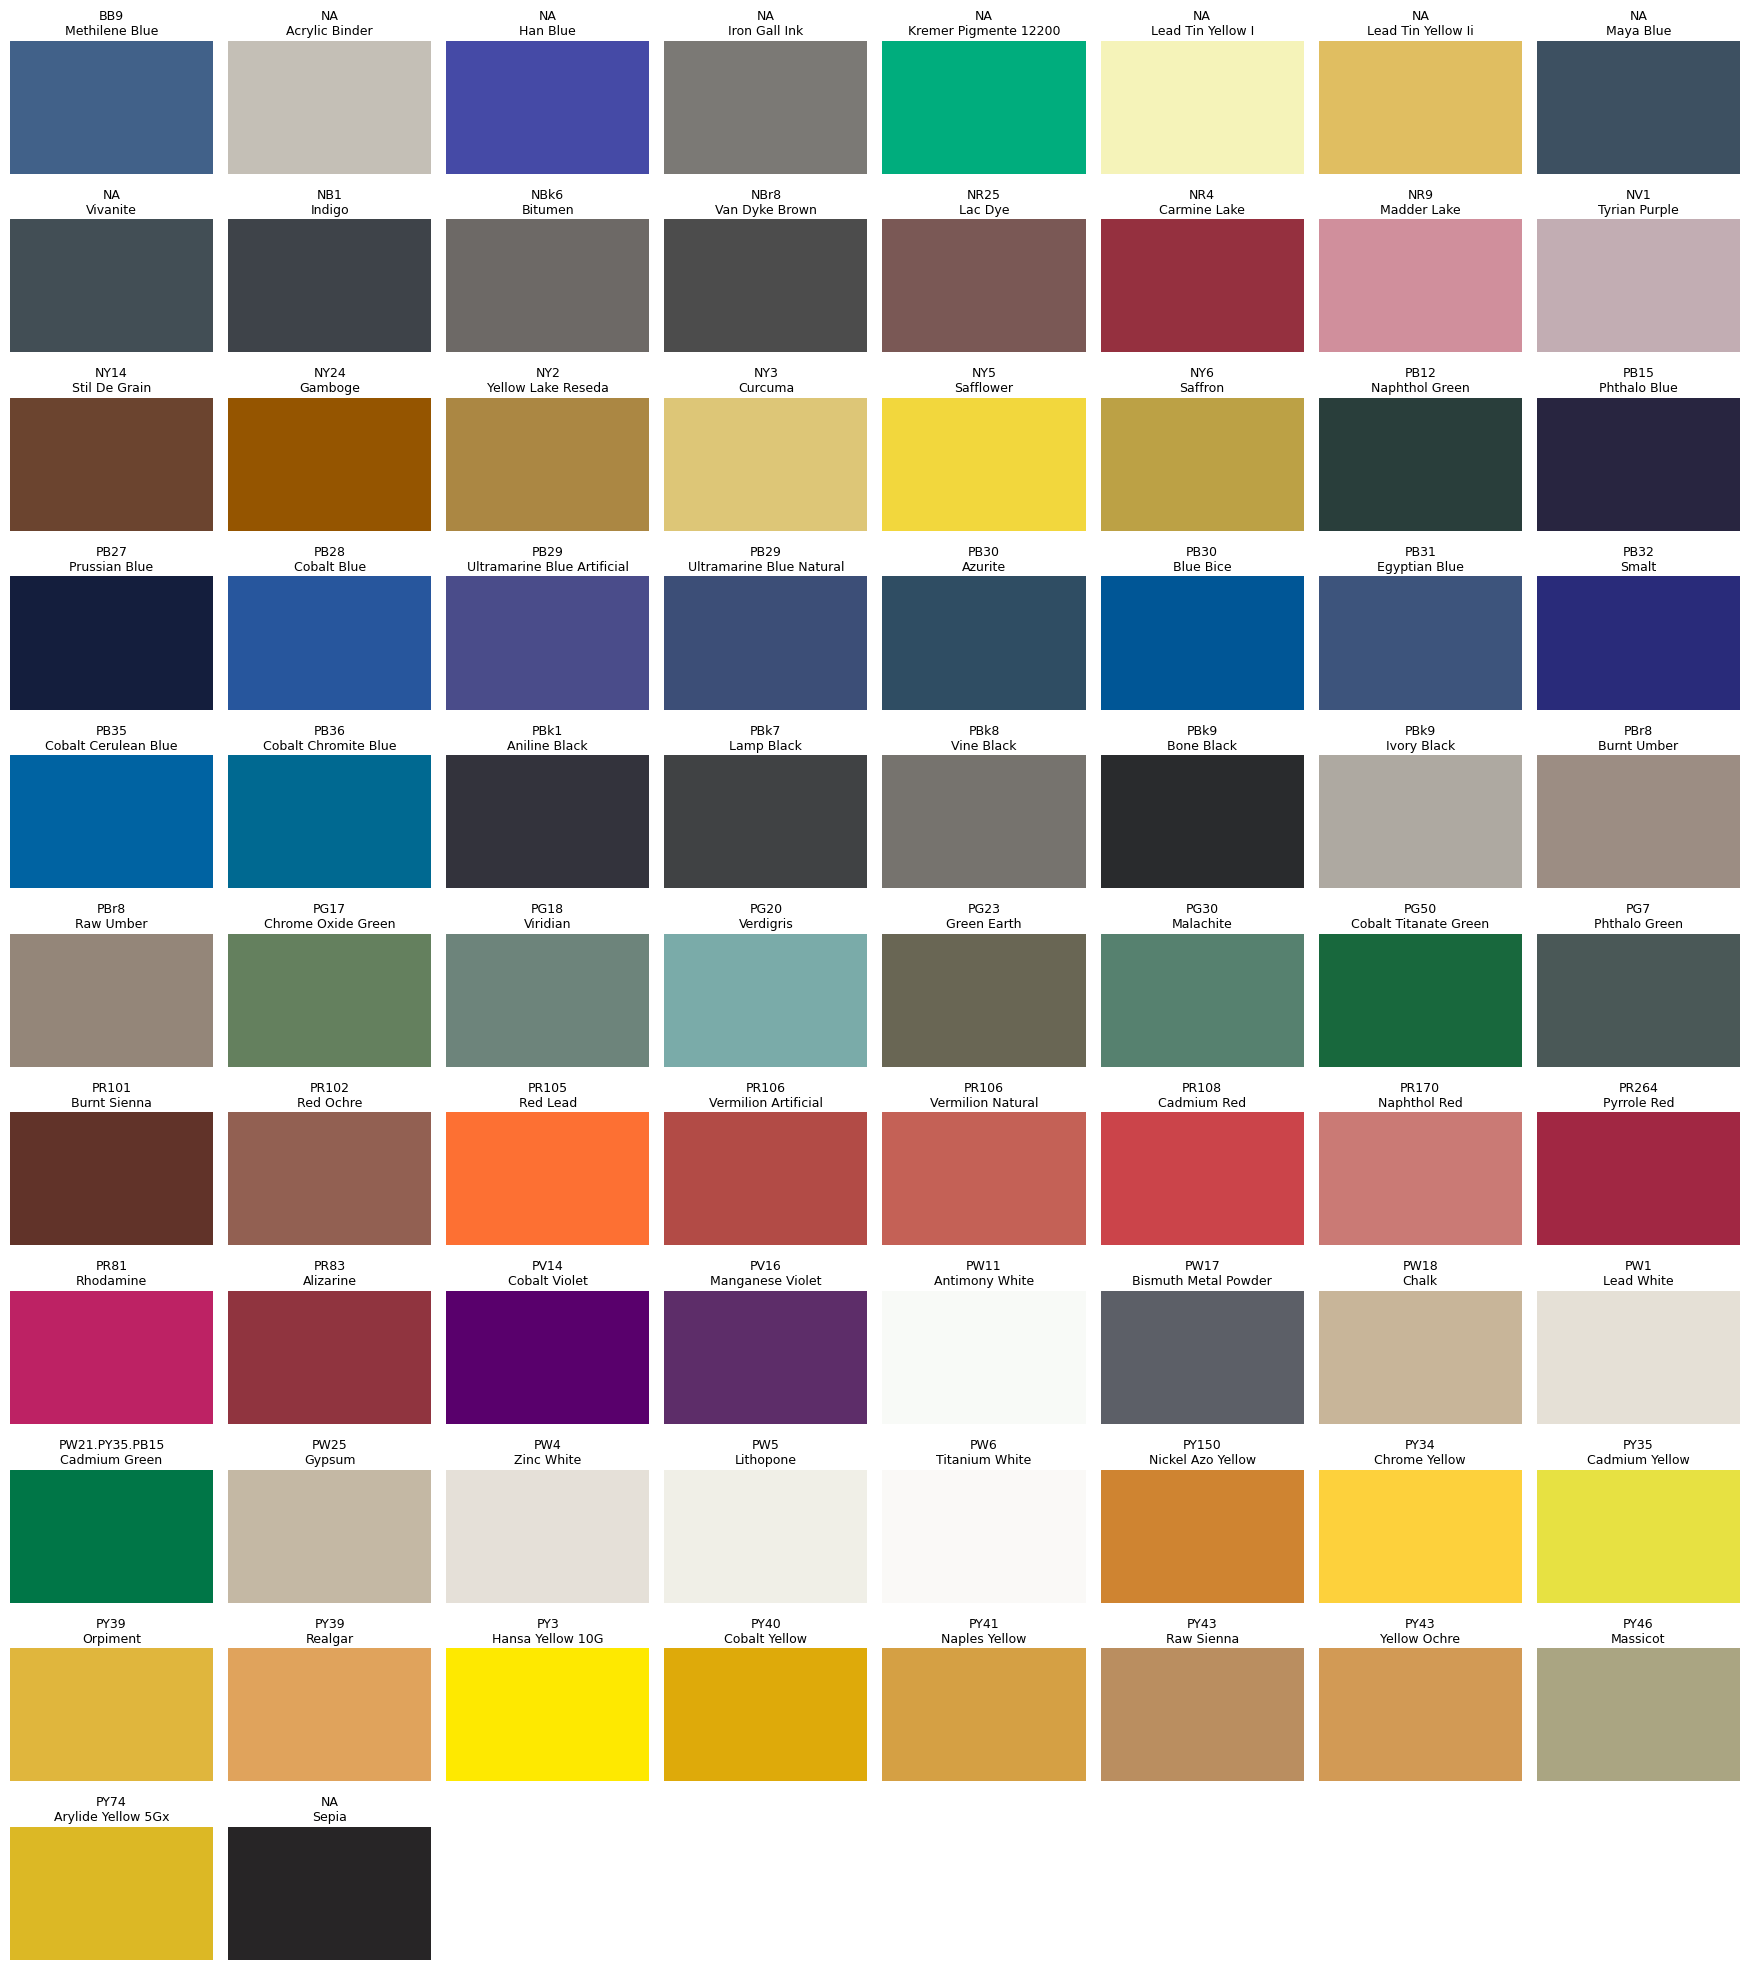

In [87]:
def visualize_final_palette(data_list, cols=8):
    """
    VISUALIZATION: Creates the final artist palette grid.
    SAFE-SORT: Uses .get() to handle missing keys.
    """
    # Sort by transparency if available, otherwise by name
    sorted_p = sorted(data_list, key=lambda x: x.get('transparency', 0), reverse=True)
    
    n_paints = len(sorted_p)
    rows = int(np.ceil(n_paints / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols*2.2, rows*1.8))
    axes = axes.flatten()
    
    for i, p in enumerate(sorted_p):
        rgb_color = np.array(p['rgb']) / 255.0
        axes[i].add_patch(plt.Rectangle((0, 0), 1, 1, color=rgb_color))
        
        # Display index and name (e.g. PG50 Cobalt Teal)
        title_text = f"{p['index']}\n{p['name'].title()}"
        axes[i].set_title(title_text, fontsize=9, pad=4)
        axes[i].axis('off')
        
    # Cleanup empty slots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()

# --- RUN ---
visualize_final_palette(stage4_data)


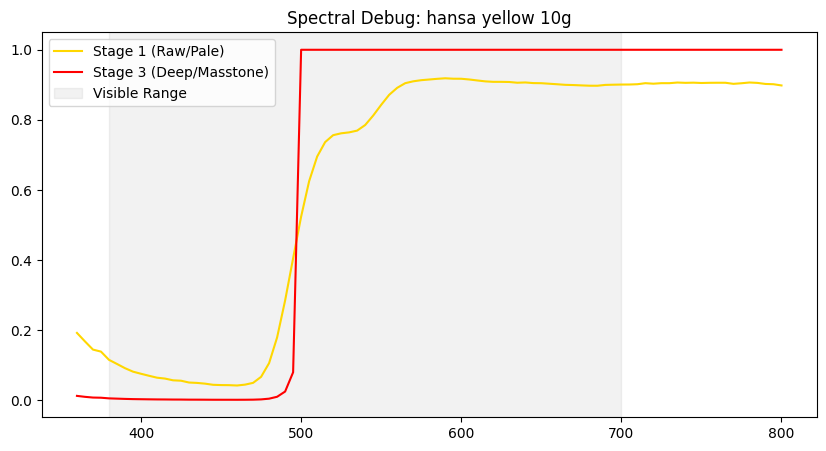

In [91]:
import matplotlib.pyplot as plt

def debug_pigment_curve(stage1_list, stage3_list, pigment_name):
    p1 = next((p for p in stage1_list if pigment_name in p['name'].lower()), None)
    p3 = next((p for p in stage3_list if pigment_name in p['name'].lower()), None)
    
    if not p1: 
        print(f"Could not find {pigment_name}")
        return

    plt.figure(figsize=(10, 5))
    plt.plot(p1['wavelengths'], p1['reflectance'], label="Stage 1 (Raw/Pale)", color='gold')
    plt.plot(p3['wavelengths'], p3['reflectance'], label="Stage 3 (Deep/Masstone)", color='red')
    
    plt.title(f"Spectral Debug: {pigment_name}")
    plt.axvspan(380, 700, color='gray', alpha=0.1, label="Visible Range")
    plt.legend()
    plt.show()

# Run this for the problematic yellow
debug_pigment_curve(stage2_data, stage3_data, "hansa yellow 10g")

In [182]:
import numpy as np
import colour

# -----------------------------
# 1. Your spectral data
# -----------------------------

wavelengths = np.arange(380, 760, 10)

ivory_black = np.array([
    0.0424, 0.0418, 0.0410, 0.0405, 0.0400, 0.0396, 0.0393, 0.0392,
    0.0392, 0.0384, 0.0382, 0.0382, 0.0380, 0.0380, 0.0381, 0.0382,
    0.0379, 0.0379, 0.0377, 0.0377, 0.0379, 0.0377, 0.0376, 0.0377,
    0.0375, 0.0376, 0.0380, 0.0380, 0.0382, 0.0382, 0.0382, 0.0378,
    0.0376, 0.0375, 0.0376, 0.0375, 0.0376, 0.0383
])

iridescent_white = np.array([
    0.3284, 0.3772, 0.4339, 0.4896, 0.5323, 0.5695, 0.6022, 0.6352,
    0.6668, 0.6957, 0.7236, 0.7487, 0.7693, 0.7886, 0.8075, 0.8192,
    0.8313, 0.8403, 0.8480, 0.8553, 0.8608, 0.8663, 0.8704, 0.8735,
    0.8785, 0.8825, 0.8878, 0.8932, 0.8963, 0.8951, 0.8941, 0.8979,
    0.8986, 0.8972, 0.8990, 0.8999, 0.9008, 0.9000
])

# -----------------------------
# 2. Helper: spectrum → sRGB
# -----------------------------

def spectrum_to_srgb(wavelengths, reflectance):
    sd = colour.SpectralDistribution(dict(zip(wavelengths, reflectance)))
    XYZ = colour.sd_to_XYZ(sd, illuminant=colour.SDS_ILLUMINANTS["D65"])
    XYZ = XYZ / 100  # normalise
    rgb = colour.XYZ_to_sRGB(XYZ)
    return np.clip(rgb, 0, 1)

# -----------------------------
# 3. Convert both pigments
# -----------------------------

rgb_black = spectrum_to_srgb(wavelengths, ivory_black)
rgb_white = spectrum_to_srgb(wavelengths, iridescent_white)

print("Ivory Black sRGB:", rgb_black)
print("Iridescent White sRGB:", rgb_white)

Ivory Black sRGB: [ 0.21412668  0.2145807   0.2186387 ]
Iridescent White sRGB: [ 0.95153209  0.92527966  0.80873534]
